# Machine Learning Algorithms From Scratch

## Outline

- [Intro](#outline): Context and setup
  - [0.1](#introduction): Introduction
  - [0.2](#setup): Setup
- [Section 1](#section-1-linear-models): Linear models
  - [1.1](#11-ordinary-least-squares) Ordinary least squares
  - [1.2](#12-ridge-regression) Ridge regression
  - [1.3](#13-lasso-regression) Lasso regression
- [Section 2](#section-2-classification-models): Classification models
  - [2.1](#21-knn-classifier) kNN classifier
  - [2.2](#22-logistic-regression) Logistic regression
- [Conclusion](#conclusion)

## Introduction [^](#outline)

The following work is based upon a previous MSc coursework piece. The aim is to implement standard machine learning models using just NumPy and native Python. The Python files have been organised into two folders, `models` and `tools`. Models contains a file for each model with all necessary functions. The tools folder contains various functions for key statistics and numerous cross-validation tools for tuning the models. The folder `derivations` contains a series of markdown files, one for each model, providing the mathematical derivations for each model. This notebook is designed to demonstrate the use of the custom made models and to make direct comparisons between the models' outputs and that of the industry standard scikit-learn packages. We will see that the custom made models acheive comparable results. This notebook imports simple datasets from sklearn (no prior download needed) and tunes the models. This work should **not** be interpreted as serious data-science investigative work, but is instead suppose to demonstrate the validity of the custom models.

<a name="setup"></a>
## Setup [^](#outline)

Here we load the necessary packages for the entire notebook.

In [ ]:
# Standard imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Custom made imports

import models.ols
import models.ridge
import models.lasso
import models.knn
import models.logistic
import tools.statistics
import tools.preprocessing
import tools.cross_validation

# Sklearn models for comparison

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, recall_score, precision_score, f1_score, log_loss
from sklearn.datasets import fetch_california_housing, load_breast_cancer

# Create a seed for any random number generators to ensure reproducibility
seed = 123

## Section 1: Linear Models [^](#outline)


In order to compare our linear models, we will look at one of sklearn's datasets: the california housing dataset. This contains various predictors such as median income of household, age of house and average number of rooms for different regions in California. The target variable is the median house price in each region. The dataset is known to be clean so we omit any data cleaning or analysis as we are simply looking to compare our models. We load the data below.

In [2]:
# Load the data
data = fetch_california_housing(as_frame=True)

# Separate target variable
X = data.data      # DataFrame with named columns
y = data.target    # Series, target variable (median house price)

# Use an 80/20 train/test split
X, X_test, y, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)


## 1.1 Ordinary least squares  [^](#outline)

We fit both OLS models below and store their coefficients.

In [3]:
# Custom model first

# Add an intercept term to our model matrix
N = X.shape[0]
X_int = np.hstack([np.ones((N,1)), X])

# Obtain the coefficients and predicted response
beta = models.ols.coefficients(X_int, y)
y_pred = models.ols.predict(X_int, beta)

# Compute the R^2 squared score using our custom function
r2_score_train = tools.statistics.R_squared(y, y_pred)

# Repeat the process on the test set:
N = X_test.shape[0]
X_test_int = np.hstack([np.ones((N,1)), X_test])
y_pred_test = models.ols.predict(X_test_int, beta)
r2_score_test = tools.statistics.R_squared(y_test, y_pred_test)

# Fit the sklearn model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


We now compare the $R^2$ scores on both the test and training data and also the model coefficients.

In [4]:
print(f'Absolute difference in intercept terms: {abs(model.intercept_-beta[0]) : .3}')
print(f'Absolute difference in remaining coefficient terms: \n {abs(model.coef_-beta[1:]) }')
print(f'Absolute difference in R^2 score on train set: {abs(r2_score(y, model.predict(X)) - r2_score_train) : .3}')
print(f'Absolute difference in R^2 score on test set: {abs(r2_score(y_test, model.predict(X_test)) - r2_score_test) : .3}')

Absolute difference in intercept terms:  1.07e-13
Absolute difference in remaining coefficient terms: 
 [1.22124533e-14 4.01415012e-15 1.95399252e-14 1.48103751e-13
 1.09839844e-16 1.30971622e-16 5.55111512e-15 2.05391260e-15]
Absolute difference in R^2 score on train set:  1.11e-16
Absolute difference in R^2 score on test set:  2.33e-15


We observe that the difference in our coefficients is less than `1e-12` for all estimates. We move on to comparing the ridge regression model now.

<a name="ridge"></a>
## 1.2 Ridge Regression[^](#outline)

We will now compare our ridge model with sklearn's. We'll standardise the data this time as is standard practice when employing ridge regression. A worthwhile note: unlike sklearn's standardise function which stores the mean and standard deviation of the training data and subsequently uses this to standardise the test set, we will not do this and instead standardise both sets separately. In practice, the difference between such approaches is small and it will not invalidate our comparison of coefficients between the two models since the inputted data will be the same. We will also create 5 folds to employ cross-validation when tuning the ridge parameter.

In [5]:
# Standardise data using custom function.
X = tools.preprocessing.standardise(X)
X_test = tools.preprocessing.standardise(X_test)
y = tools.preprocessing.standardise(y)
y_test = tools.preprocessing.standardise(y_test)

# Create the folds
folds = np.array_split(np.arange(len(y)), 5)

Below we employ 5-fold cross validation and perform a grid search over the interval $[0,5000]$ in increments of size $50$ for both our custom model and sklearn. We produce side by side plots of the mean squared error for these different values of the hyperparameter. To avoid confusion, we will refer to our custom model's parameter as $\lambda$ and sklearn's parameter as $\alpha$.

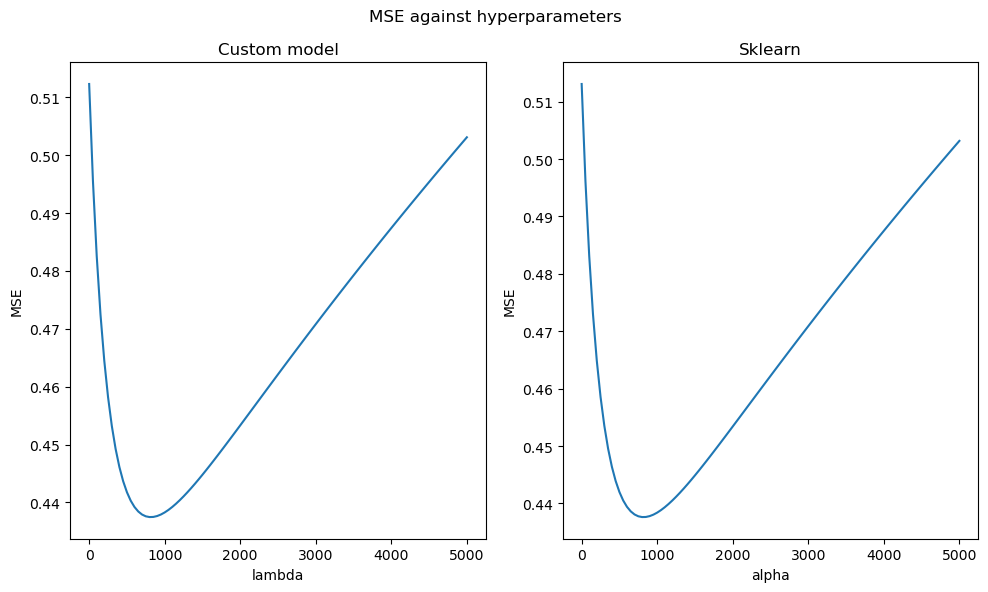

In [6]:
# Perform a simple grid search for the ridge parameter lambda in the interval [0,5000].
lam = np.linspace(0,5000,101)
lam_scores = np.zeros(len(lam))
for i in range(len(lam)):
    lam_scores[i] = tools.cross_validation.cross_val_score(X, y, folds, model_type='ridge', lam=lam[i])

# Repeat the grid search using sklearn
alpha = np.linspace(0,5000,101)
alpha_scores = np.zeros(len(alpha))
for i in range(len(alpha)):
    model = Ridge(alpha=alpha[i])
    alpha_scores[i] = -np.mean(cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error'))

# Produce a plot
fig, ax = plt.subplots(1,2, figsize=(10,6), tight_layout=True)
ax[0].plot(lam, lam_scores)
ax[0].set_title('Custom model')
ax[0].set_xlabel('lambda')
ax[0].set_ylabel('MSE')

ax[1].plot(alpha, alpha_scores)
ax[1].set_title('Sklearn')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('MSE')

plt.suptitle('MSE against hyperparameters')
plt.show()

The above plots appear identical, as we expect. Below we print the optimum values found.

In [7]:
# Find optimum lambda
lam_optimum = lam[np.argmin(lam_scores)]
print(f'MSE is minimised when lambda is {lam_optimum : .3g}')

# Find optimum alpha
alpha_optimum = alpha[np.argmin(alpha_scores)]
print(f'MSE is minimised when alpha is {alpha_optimum : .3g}')

MSE is minimised when lambda is  800
MSE is minimised when alpha is  800


We will now compare the differences in the coefficients and both the $R^2$ and mean squared errors on the test set predictions.

In [8]:
# Obtain the metrics for the custom model
beta = models.ridge.coefficients(X, y, lam_optimum)
y_pred = models.ridge.predict(X_test, beta)
r2_score_custom = tools.statistics.R_squared(y_test, y_pred)
mse_custom = tools.statistics.MSE(y_test, y_pred)

# Obtain the metrics for the sklearn model
model = Ridge(alpha=alpha_optimum, fit_intercept=False)
model.fit(X,y)
y_pred = model.predict(X_test)
r2_score_sklearn = r2_score(y_test, y_pred)
mse_sklearn = mean_squared_error(y_test, y_pred)

# Print the differences between them
print(f'Difference between coefficients: \n {abs(beta - model.coef_)}')
print(f'Difference in R2 score: {abs(r2_score_custom-r2_score_sklearn) : .3}')
print(f'Difference in MSE: {abs(mse_custom-mse_sklearn) :.3}')

Difference between coefficients: 
 [1.11022302e-16 2.22044605e-16 7.49400542e-16 8.32667268e-17
 4.81385765e-17 8.32667268e-17 1.60982339e-15 1.94289029e-15]
Difference in R2 score:  1.11e-16
Difference in MSE: 1.67e-16


Again we see that all of the differences are less than `1e-14` demonstrating an excellent comparison.

## 1.3 Lasso Regression[^](#outline)

We now repeat the same process as we did for the ridge model but with the lasso model instead.

In [9]:
# Scan over a range of values for lambda
lam = np.linspace(0.001,0.1,100)
lam_scores = np.zeros(len(lam))

for i in range(len(lam)):
    lam_scores[i] = tools.cross_validation.cross_val_score(X, y, folds, model_type='lasso', lam=lam[i], max_iters=10000, learning_rate=1e-1, tol=1e-3)

In [10]:
lam_optimum = lam[np.argmin(lam_scores)]
print(f'Optimum choice of lambda: {lam_optimum :.3f}')

Optimum choice of lambda: 0.015


In [11]:
# Scan over a range of values for alpha
alpha = np.linspace(0.001,0.1,100)
alpha_scores = np.zeros(len(alpha))

for i in range(len(alpha)):
    model = Lasso(alpha=alpha[i])
    alpha_scores[i] = np.mean(cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5))

alpha_optimum = alpha[np.argmax(alpha_scores)]
print(f'Optimum choice of alpha: {alpha_optimum}')

Optimum choice of alpha: 0.015


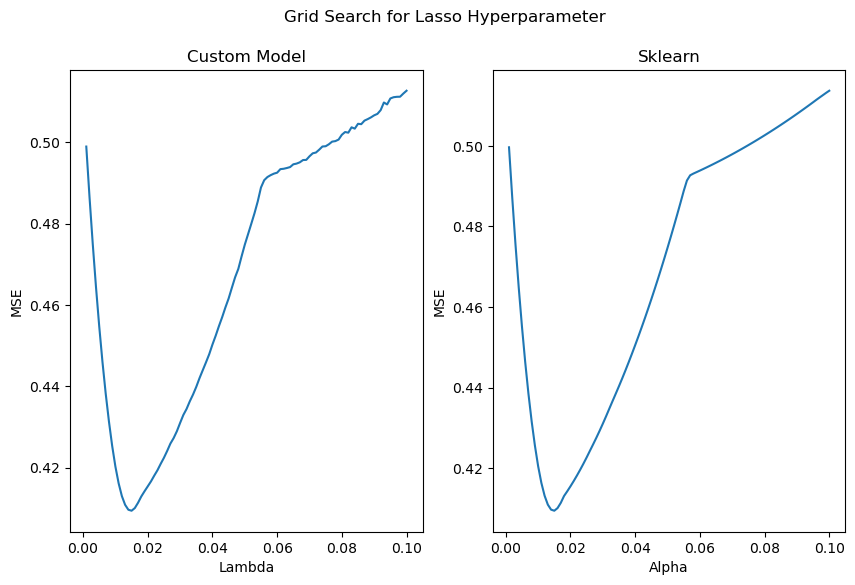

In [12]:
fig, ax = plt.subplots(1,2, figsize=(10,6))

ax[0].plot(lam, lam_scores)
ax[0].set_title('Custom Model')
ax[0].set_xlabel('Lambda')
ax[0].set_ylabel('MSE')

ax[1].plot(alpha, -alpha_scores)
ax[1].set_title('Sklearn')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('MSE')

plt.suptitle('Grid Search for Lasso Hyperparameter')

plt.tight_layout
plt.show()

The above plot shows our custom model is indeed converging to similar results as sklearn. To provide a more thorough comparison, we will examine the difference in size of the model coefficients.

In [13]:
# Obtain the metrics for the custom model
beta = models.lasso.coefficients(X, y, lam_optimum, learning_rate=5e-1, tol=1e-4, max_iters=100000)

# Obtain the metrics for the sklearn model
model = Lasso(alpha=alpha_optimum, fit_intercept=False)
model.fit(X,y)

# Print the differences between them
print(f'Difference between coefficients: \n {abs(beta - model.coef_)}')

Failed to converge before max iterations reached
Difference between coefficients: 
 [0.0004296  0.00061743 0.00039293 0.00025492 0.00827504 0.00013532
 0.00131352 0.00154767]


Unfortunately here are coefficients here do not agree as well with sklearn's as the OLS and ridge models did. We still note that all coefficients are within `1e-2` at worst. This is likely because of the non-differentiability of the $l_1$ norm which has to be resolved. In our model, we used a simple subgradient method, defining the gradient at 0 to be 0, however sklearn's model is more sophisticated and doesn't use gradient descent, but instead uses coordinate descent in conjuction with soft-thresholding, a technique whereby coefficients close to 0 are snapped to 0. Our simple model is prone to oscillating about 0 depending on the size of the learning rate. This is a known limitation of these methods.

# Section 2: Classification Models [^](#outline)

## 2.1 kNN Classifier [^](#outline)

In this section we implement a k-nearest neighbours function for classification. We first load in the data and standardise it. The standardisation is essential because without it, predictors with larger quantities will always be deemed further away by the Euclidean metric. We will use sklearn's built in breast cancer dataset for its ease of use for classification problems (the datasrt has already been cleaned and has a binary target column).

In [14]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# Standardise the predictor variables using the mean and std of the training data
X = tools.preprocessing.standardise(X)

# Use an 80/20 train/test split
X, X_test, y, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# Define the folds
folds = np.array_split(np.arange(len(y)), 5)

Now we tune the model to the training data and print metrics of interest in a classification problem.

In [15]:
# Train the model

best_k = tools.cross_validation.choose_best_k(X, y, folds, range(1, 11))
print('Best k:', best_k)

For 1 neighbours, accuracy = 0.945, recall = 0.975, precision = 0.939, f1 = 0.956 
For 2 neighbours, accuracy = 0.941, recall = 0.937, precision = 0.968, f1 = 0.952 
For 3 neighbours, accuracy = 0.956, recall = 0.984, precision = 0.950, f1 = 0.966 
For 4 neighbours, accuracy = 0.956, recall = 0.973, precision = 0.960, f1 = 0.966 
For 5 neighbours, accuracy = 0.956, recall = 0.994, precision = 0.940, f1 = 0.966 
For 6 neighbours, accuracy = 0.965, recall = 0.990, precision = 0.956, f1 = 0.973 
For 7 neighbours, accuracy = 0.958, recall = 0.990, precision = 0.946, f1 = 0.968 
For 8 neighbours, accuracy = 0.965, recall = 0.990, precision = 0.957, f1 = 0.973 
For 9 neighbours, accuracy = 0.956, recall = 0.990, precision = 0.943, f1 = 0.966 
For 10 neighbours, accuracy = 0.963, recall = 0.987, precision = 0.957, f1 = 0.972 
Best k: 6


It appears from the above that the optimal value for $k$ is 6 if we wish to maximise accuracy. We will now repeat this process using sklearn's models.

In [16]:
keys = ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']
best_acc = 0
best_k =  None
for k in range(1,11):
    model = KNeighborsClassifier(k)
    cross_val_scores = cross_validate(model, X, y, scoring=['accuracy','recall','precision','f1'], cv=5)
    scores = [cross_val_scores[k].mean() for k in keys]
    if scores[0] > best_acc :
        best_acc = scores[0]
        best_k = k
    print(f'For {k} neighbours, accuracy = {scores[0]:.3f}, recall = {scores[1]:.3f}, precision = {scores[2]:.3f}, f1 = {scores[3]:.3f} ')
print(f'Best k: {best_k}')

For 1 neighbours, accuracy = 0.945, recall = 0.975, precision = 0.940, f1 = 0.957 
For 2 neighbours, accuracy = 0.938, recall = 0.933, precision = 0.968, f1 = 0.950 
For 3 neighbours, accuracy = 0.956, recall = 0.982, precision = 0.950, f1 = 0.966 
For 4 neighbours, accuracy = 0.956, recall = 0.972, precision = 0.959, f1 = 0.965 
For 5 neighbours, accuracy = 0.954, recall = 0.993, precision = 0.937, f1 = 0.964 
For 6 neighbours, accuracy = 0.965, recall = 0.989, precision = 0.956, f1 = 0.972 
For 7 neighbours, accuracy = 0.958, recall = 0.989, precision = 0.946, f1 = 0.967 
For 8 neighbours, accuracy = 0.965, recall = 0.989, precision = 0.956, f1 = 0.973 
For 9 neighbours, accuracy = 0.956, recall = 0.989, precision = 0.943, f1 = 0.966 
For 10 neighbours, accuracy = 0.963, recall = 0.986, precision = 0.956, f1 = 0.971 
Best k: 6


We see that sklearn's model returns the same optimum choice of $k$ although we note some minor discrepancies in the date. See for example, the two accuracy scores for $k=2$ neighbours have differed by a small amount. This can depend on the exact mechanism for how to deal with ties for instance.

We will now predict on the test set using this optimum value for $k$ for both models and compare their predictions.

In [18]:
y_pred_custom = models.knn.predict(X, y, X_test, k = best_k)
acc, recall, precision, f1 = tools.statistics.classification_score(y_test, y_pred_custom)

model = KNeighborsClassifier(best_k)
model.fit(X, y)
y_pred_sklearn = model.predict(X_test)

print(f'Percentage correct predictions: {np.mean(y_pred_custom == y_pred_sklearn)*100 :.2f}%')

Percentage correct predictions: 100.00%


We observe a perfect comparison with sklearn's model.

## 2.2 Logistic Regression [^](#outline)

In this section we will examine the performance of our logistic model. We will begin by obtaining our logistic model parameter estimates in the same dataset used for the KNN model. Some experimentation was required with the exact inputs to achieve convergence to the required coefficients. The successful result is printed below. We start our algorithm with an initial guess of 0 for all parameters.

In [19]:
parameters, grads, costs = models.logistic.optimise(X, y, learning_rate=100, print_cost=False, tol=1e-7)

c:\Users\ccbar\Portfolio\ML-Algorithms\models\logistic.py:16: RuntimeWarning: overflow encountered in exp
  return np.where(x>0, 1. / (1. + np.exp(-x)), np.exp(x) / (1. + np.exp(x)))
c:\Users\ccbar\Portfolio\ML-Algorithms\models\logistic.py:16: RuntimeWarning: invalid value encountered in divide
  return np.where(x>0, 1. / (1. + np.exp(-x)), np.exp(x) / (1. + np.exp(x)))


Convergence to within tolerance reached.


We verify that we have indeed obtained a smooth convergence by plotting the loss function against the iterations.

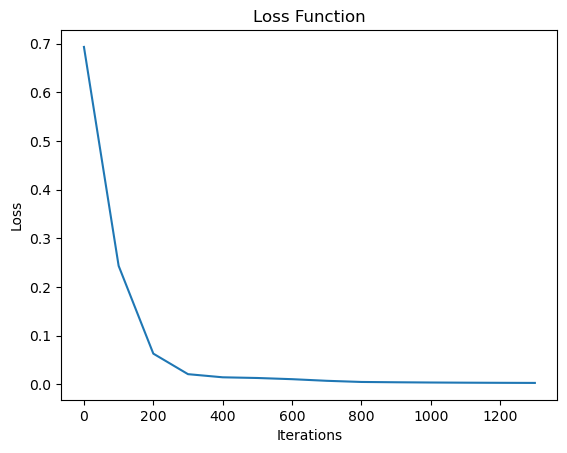

In [20]:
x_axis = range(0, 100*len(costs), 100)
plt.plot(x_axis, costs)
plt.title('Loss Function')
plt.xlabel('Iterations')
plt.xticks()
plt.ylabel('Loss')
plt.show()

The loss function shows smooth convergence and so we proceed to train the model with our chosen parameters and compare its predictions to those of sklearn's.

In [22]:
beta = parameters["beta"]
beta_0 = parameters["beta_0"]

y_pred_custom = models.logistic.predict(X_test, beta, beta_0)
custom_score = tools.statistics.classification_score(y_test, y_pred_custom)

model = LogisticRegression(penalty=None, max_iter=10000, tol=1e-7)
model.fit(X,y)
y_pred_sklearn = model.predict(X_test)

print(f'Percentage correct predictions: {np.mean(y_pred_custom == y_pred_sklearn)*100 :.2f}%')


Percentage correct predictions: 100.00%


We see that it achieved a perfect match to sklearn's predictions. We will now examine the loss function and the coefficients. They were found to differ by a more substantial amount, and so both results are printed below.

In [23]:
y_prob = models.logistic.predict_log(X, beta, beta_0)
my_loss = log_loss(y, y_prob)

y_prob = model.predict_proba(X)
sklearn_loss = log_loss(y, y_prob)
print(f'Custom model loss: {my_loss :.3g} vs Sklearn loss {sklearn_loss :.3g}')

Custom model loss: 0.00285 vs Sklearn loss 1.14e-07


d:\conda_envs\ds-env\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


These difference will be due to different convergence stopping criteria. For our model, we implemented a simple stop when the change in the loss function was less than `1e-7`. Another sensible checks could involve using the change in size of the coefficients as a stopping criterion or, better yet, a combination of the two.

Below we will print out both models' coefficients and we will see that there are substantial differences here, despite obtaining identical predictions.

In [24]:
model.coef_, model.intercept_

(array([[ 274.84481613,   65.40069799,  275.06529906,  233.9071835 ,
         -143.35364651,  376.97996309, -552.20667597, -218.9517095 ,
          -35.80399014, -123.46848102, -428.3276446 ,  398.16374394,
            9.37576706, -785.19196926, -236.09264967, -223.49863368,
          152.18512108,  -12.94079753,  145.75385145,  721.15925802,
         -661.51160492, -707.18400153, -413.10516376, -632.78606189,
          -18.45285297,  475.70260612, -215.80219926, -477.52027041,
         -155.9833522 , -452.07471397]]),
 array([-221.66479738]))

In [25]:
beta.T, beta_0

(array([[ 15.34861098,   1.57501227,  16.99732733,  11.52010239,
          -2.15131173,  22.706767  , -24.11417   , -12.08108036,
           4.65831983,  -2.30157391, -17.14206419,  12.14104764,
           0.17282084, -31.93736082,  -7.66172983, -13.40661412,
           9.24279674,  -4.90692598,   7.45760755,  30.00676827,
         -32.54527773, -23.62200712, -17.26313073, -27.07693786,
          -1.88513419,  15.64082403,  -7.07040095, -24.36278575,
          -9.8057448 , -18.72053529]]),
 np.float64(-6.956223939582663))

Although the difference is at first alarming, this should not be surprising when we examine that there is a high level of multicollinearity. We print the condition number of the test set to verify this.

In [26]:
np.linalg.cond(X_test)

np.float64(455.35380829489054)

The condition number is excessively high providing a satisfactory explanation for the variation in coefficients.

## Conclusion [^](#outline)

In summary, we have constructed several machine learning algorithms from scratch in NumPy. Namely, OLS, ridge and lasso regression alongside KNN and logisitic regression for classification problems. Both OLS and ridge regression models achieved similar model coefficients to that of sklearns' (to within `1e-14`). Additionally, our grid search algorithm produced the same optimum hyperparameter as sklearn's for ridge regression. Lasso obtained the same hyperparameter to within `1e-3`, notably less accurate than the previous two.

The KNN model acheived nearly identical cross-validation scores on accuracy, precision, recall and f1-scores with minor discrepancies. Potential sources of these include: differences in tie-breaking algorithms or minor differences in the exact folds used. Despite this, there was a 100% comparison between predictions on the test set.

The logistic regression model also achieved a 100% comparison in predictions with sklearn's model although there was substantial coefficient variation. This could be explained by difference in stopping criteria for the gradient descent methods (sklearn's loss function was noticeably smaller than ours) and also by the high degree of multicollinearity in the dataset (condition number of 455).

All in all, this was an excellent learning exercise. Notable challenges were definitely successfully obtaining convergence of the lasso and logisitic regression models' coefficients and deciding on exactly what stopping criteria to employ. In the end, we choose a very primitive criteria but consequently our results were unsatisfactory. This presents an excellent opportunity for further developement and refinement. Additional checks could include adding additional tolerance checks on the coefficients themselves, not just the loss function, or even including a combination of these. Examining more carefully the exact decision criteria of sklearn's models for KNN and how ties are handled would be of great interest also.